# Exploring Global Terrorism Patterns & Trends

This notebook analyzes the provided Excel dataset containing country-level records from 2012 to 2022.

## Objectives
- Explore the structure and quality of the supplied dataset.
- Analyze recorded incidents, fatalities and injuries over time.
- Compare countries using aggregated incident and impact measures.
- Visualize year-wise and country-wise patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the combined dataset
df = pd.read_excel('C:\\Users\\Hp\\Desktop\\Advanced_Data_Sciecne-LAB\\Assignment_3\\Project5\\1776311688-P5-Exploring Global Terrorism Patterns & Trends.xlsx',
                   sheet_name='Combined raw')

df.head()

,iso3c,Country,Rank,Score,Incidents,Fatalities,Injuries,Hostages,Year
0,IRQ,Iraq,1,9.599967,1288,2086,5050,16,2012
1,PAK,Pakistan,2,9.152620,638,1322,2297,160,2012
2,AFG,Afghanistan,3,9.134265,507,1511,2612,67,2012
3,SYR,Syria,4,8.238079,168,1014,1833,71,2012
4,YEM,Yemen,5,8.098513,219,651,798,121,2012


## Dataset Overview

In [2]:
print('Dataset Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
df.info()

Dataset Shape: (1793, 9)

Columns:
['iso3c', 'Country', 'Rank', 'Score', 'Incidents', 'Fatalities', 'Injuries', 'Hostages', 'Year']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1793 entries, 0 to 1792
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   iso3c       1793 non-null   object 
 1   Country     1793 non-null   object 
 2   Rank        1793 non-null   int64  
 3   Score       1793 non-null   float64
 4   Incidents   1793 non-null   int64  
 5   Fatalities  1793 non-null   int64  
 6   Injuries    1793 non-null   int64  
 7   Hostages    1793 non-null   int64  
 8   Year        1793 non-null   int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 126.2+ KB


## Data Quality Check

In [3]:
print('Missing Values:')
print(df.isnull().sum())

print('\nDuplicate Rows:', df.duplicated().sum())

Missing Values:
iso3c         0
Country       0
Rank          0
Score         0
Incidents     0
Fatalities    0
Injuries      0
Hostages      0
Year          0
dtype: int64

Duplicate Rows: 0


## Overall Summary

In [4]:
print(f"Period Covered: {df['Year'].min()} to {df['Year'].max()}")
print(f"Total Records: {len(df):,}")
print(f"Total Incidents: {df['Incidents'].sum():,.0f}")
print(f"Total Fatalities: {df['Fatalities'].sum():,.0f}")
print(f"Total Injuries: {df['Injuries'].sum():,.0f}")

df[['Score','Incidents','Fatalities','Injuries','Hostages']].describe()

Period Covered: 2012 to 2022
Total Records: 1,793
Total Incidents: 47,873
Total Fatalities: 95,993
Total Injuries: 133,738


,Score,Incidents,Fatalities,Injuries,Hostages
count,1793.000000,1793.000000,1793.000000,1793.000000,1793.000000
mean,2.442817,26.699944,53.537646,74.588957,10.149470
std,2.654876,109.500965,253.912698,415.669549,82.306937
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.534965,0.000000,0.000000,0.000000,0.000000
75%,4.419243,4.000000,2.000000,4.000000,0.000000
max,10.000000,1673.000000,4514.000000,9479.000000,2727.000000


## Year-wise Incident Trend

Year
2012    4711
2013    4371
2014    3546
2015    3632
2016    4210
2017    4517
2018    4829
2019    4118
2020    4541
2021    5443
2022    3955
Name: Incidents, dtype: int64


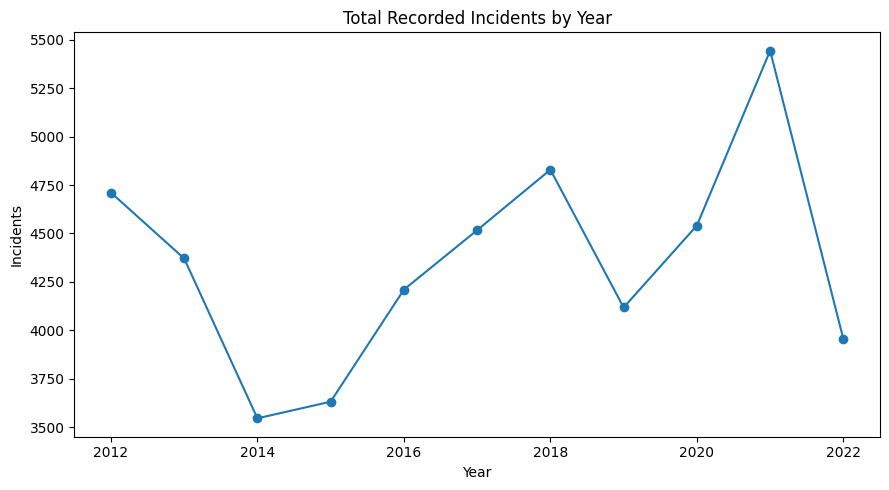

In [5]:
year_incidents = df.groupby('Year')['Incidents'].sum().sort_index()
print(year_incidents)

plt.figure(figsize=(9,5))
plt.plot(year_incidents.index, year_incidents.values, marker='o')
plt.title('Total Recorded Incidents by Year')
plt.xlabel('Year')
plt.ylabel('Incidents')
plt.tight_layout()
plt.show()

## Year-wise Fatality Trend

Year
2012     9227
2013    10317
2014    10129
2015    10881
2016    10372
2017     8932
2018     7480
2019     7193
2020     7433
2021     7328
2022     6701
Name: Fatalities, dtype: int64


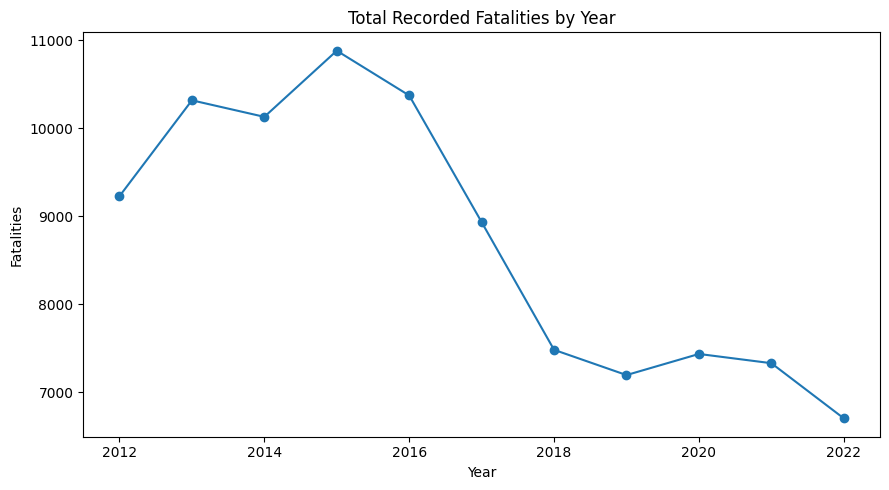

In [6]:
year_fatalities = df.groupby('Year')['Fatalities'].sum().sort_index()
print(year_fatalities)

plt.figure(figsize=(9,5))
plt.plot(year_fatalities.index, year_fatalities.values, marker='o')
plt.title('Total Recorded Fatalities by Year')
plt.xlabel('Year')
plt.ylabel('Fatalities')
plt.tight_layout()
plt.show()

## Countries with Highest Recorded Incidents

Country
Iraq           11183
Afghanistan     4443
Pakistan        3358
Somalia         2951
India           2872
Nigeria         1718
Colombia        1716
Mali            1636
Myanmar         1575
Syria           1551
Name: Incidents, dtype: int64


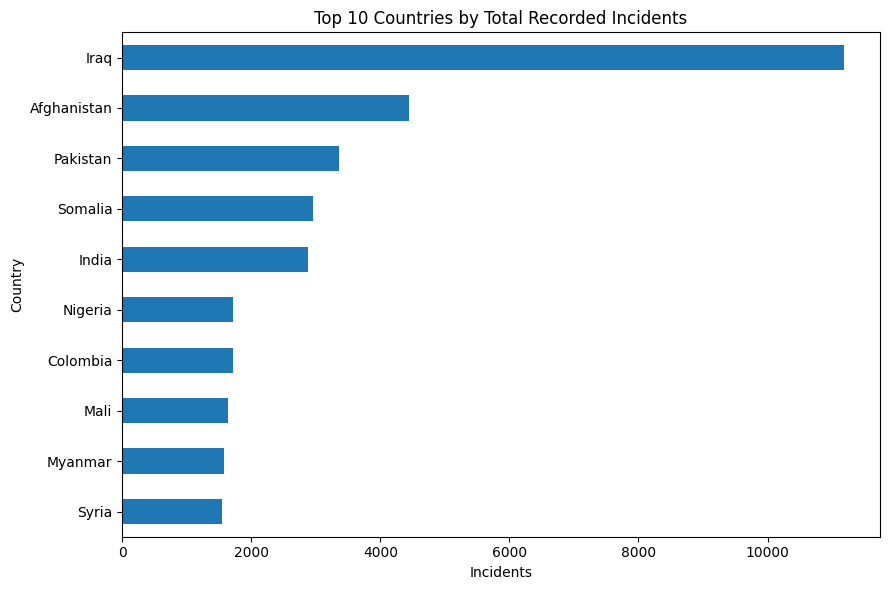

In [7]:
top_countries = df.groupby('Country')['Incidents'].sum().sort_values(ascending=False).head(10)
print(top_countries)

plt.figure(figsize=(9,6))
top_countries.sort_values().plot(kind='barh')
plt.title('Top 10 Countries by Total Recorded Incidents')
plt.xlabel('Incidents')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

## Countries with Highest Recorded Fatalities

Country
Iraq            21286
Afghanistan     12726
Nigeria         10191
Pakistan         7692
Somalia          7209
Syria            5977
Burkina Faso     3515
Mali             3428
Yemen            2547
Egypt            2494
Name: Fatalities, dtype: int64


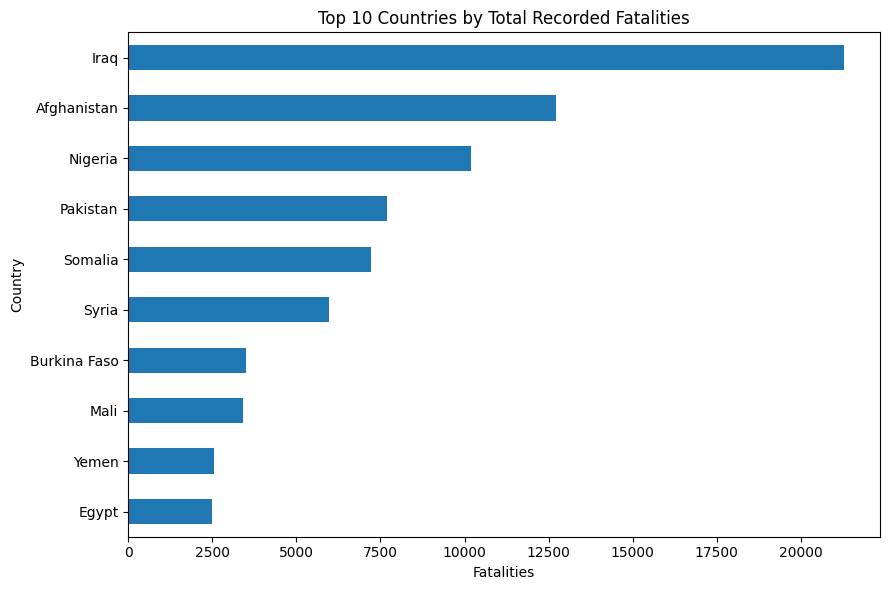

In [8]:
top_fatalities = df.groupby('Country')['Fatalities'].sum().sort_values(ascending=False).head(10)
print(top_fatalities)

plt.figure(figsize=(9,6))
top_fatalities.sort_values().plot(kind='barh')
plt.title('Top 10 Countries by Total Recorded Fatalities')
plt.xlabel('Fatalities')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

## Conclusion

The analysis summarizes patterns present in the supplied country-year dataset for 2012–2022. Aggregating incidents, fatalities and injuries by year and country makes it possible to compare changes over time and differences across countries.

The notebook demonstrates a complete exploratory analytics workflow including data loading, data quality checks, aggregation and visualization.